In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import os

import albumentations as A
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from albumentations.pytorch import ToTensorV2
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import transforms

from custom_datasets import CBISDDSM_ResNet_Dataset
from cv_utils import get_cv_folds, train_fold, summarize_cv
from util import (create_dataframes, pair_images, patient_grouped_split, get_model_file_path,
                  run_inference, evaluate_model, generate_background_patches, compute_class_weights)

In [3]:
df, full_mammograms_df, roi_masks_df, cropped_df = create_dataframes()

print(f"Total ROIs: {len(roi_masks_df)}")
print(roi_masks_df['image_path'].head(5))

Total ROIs: 3247
5     ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
8     ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
9     ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
14    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
20    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: str


In [4]:
paired_df, merged_df = pair_images(roi_masks_df, full_mammograms_df)

Successfully paired 3242 mammogram/ROI pairs.
Removed 78 entries due to mismatched dimensions.
Consolidated into 2742 image entries.


In [5]:
cropped_df = cropped_df[cropped_df['PatientID'].isin(merged_df['PatientID_roi'])]

bg_csv_path = "../data/cbis-ddsm/background_crops/background_crops.csv"
if os.path.exists(bg_csv_path):
    bg_df = pd.read_csv(bg_csv_path)
    print(f"Loaded {len(bg_df)} existing background crops from {bg_csv_path}")
else:
    print("Generating background crops...")
    bg_df = generate_background_patches(paired_df, output_dir="../data/cbis-ddsm/background_crops", max_total_samples=600)

cropped_df = pd.concat([cropped_df, bg_df], ignore_index=True)
print("Combined dataset class distribution:")
print(cropped_df['pathology'].value_counts())

Loaded 600 existing background crops from ../data/cbis-ddsm/background_crops/background_crops.csv
Combined dataset class distribution:
pathology
BENIGN        1851
MALIGNANT     1313
BACKGROUND     600
Name: count, dtype: int64


In [6]:
train_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
        A.GaussNoise(std_range=(0.01, 0.05), p=0.2),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

test_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

inv_transform = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

C:\Users\nerfb\Downloads\Programs\EUEProjects\FP\Project\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [7]:
dataset = CBISDDSM_ResNet_Dataset(dataframe=cropped_df, normalize_contrast=True)

transformed_dataset = CBISDDSM_ResNet_Dataset(dataframe=cropped_df, transform=test_transform, normalize_contrast=True)

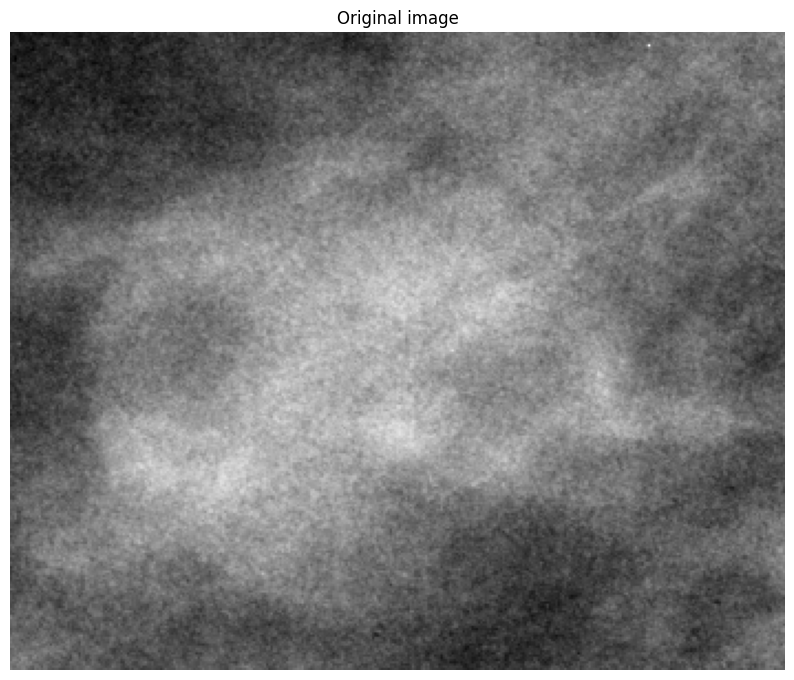

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151553..2.1345534].


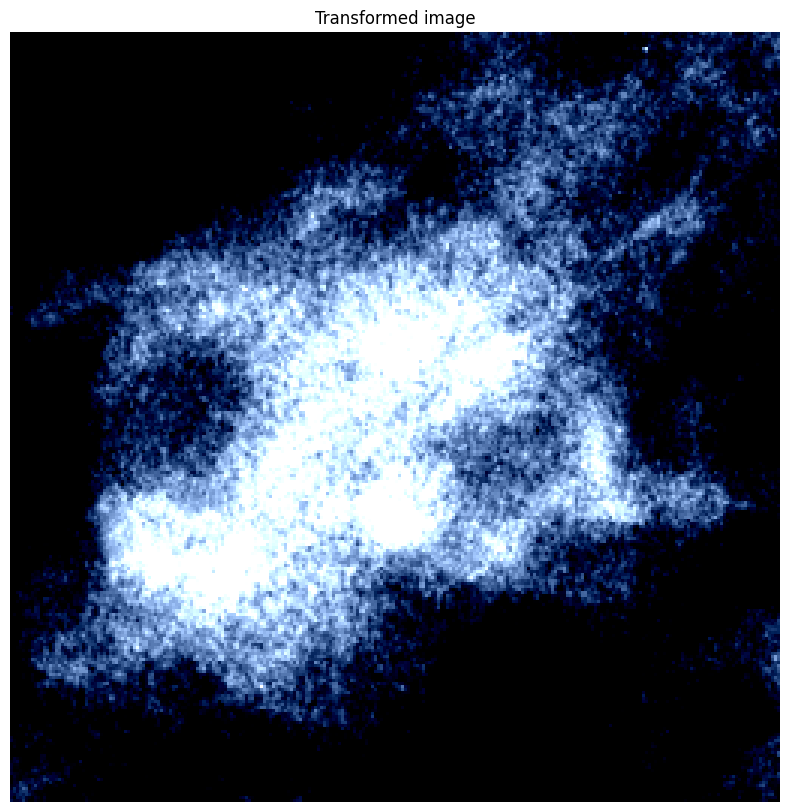

In [8]:
dataset.visualize_sample(0, "Original image")

transformed_dataset.visualize_sample(0, "Transformed image")

# Train test split

In [9]:
train_df, val_df, test_df = patient_grouped_split(cropped_df, val_size=0.15, test_size=0.15, random_state=42)

Train  2691 rows (71.5%),  997 patients [BENIGN: 1323, MALIGNANT: 938, BACKGROUND: 430]
Val     536 rows (14.2%),  196 patients [BENIGN: 264, MALIGNANT: 187, BACKGROUND: 85]
Test    537 rows (14.3%),  200 patients [BENIGN: 264, MALIGNANT: 188, BACKGROUND: 85]
No patient is shared between any of the 3 splits.


In [10]:
train_dataset = CBISDDSM_ResNet_Dataset(dataframe=train_df, transform=train_transform, normalize_contrast=True)

val_dataset = CBISDDSM_ResNet_Dataset(dataframe=val_df, transform=test_transform, normalize_contrast=True)

test_dataset = CBISDDSM_ResNet_Dataset(dataframe=test_df, transform=test_transform, normalize_contrast=True)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True,
)

# Cross-validate over train + val only. Folding over the whole `cropped_df` would put test
# patients into the training half of four folds out of five, so the test set would no longer
# be held out and its reported numbers would be optimistic.
cv_df = pd.concat([train_df, val_df], ignore_index=True)

folds = get_cv_folds(cv_df, n_splits=5, random_state=42)

Fold 1: train  2584 rows /  951 patients [BENIGN: 1270, MALIGNANT: 901, BACKGROUND: 413]  |  val  643 rows /  242 patients [BENIGN: 317, MALIGNANT: 224, BACKGROUND: 102]
Fold 2: train  2582 rows /  953 patients [BENIGN: 1270, MALIGNANT: 900, BACKGROUND: 412]  |  val  645 rows /  240 patients [BENIGN: 317, MALIGNANT: 225, BACKGROUND: 103]
Fold 3: train  2584 rows /  953 patients [BENIGN: 1270, MALIGNANT: 901, BACKGROUND: 413]  |  val  643 rows /  240 patients [BENIGN: 317, MALIGNANT: 224, BACKGROUND: 102]
Fold 4: train  2579 rows /  960 patients [BENIGN: 1269, MALIGNANT: 899, BACKGROUND: 411]  |  val  648 rows /  233 patients [BENIGN: 318, MALIGNANT: 226, BACKGROUND: 104]
Fold 5: train  2579 rows /  955 patients [BENIGN: 1269, MALIGNANT: 899, BACKGROUND: 411]  |  val  648 rows /  238 patients [BENIGN: 318, MALIGNANT: 226, BACKGROUND: 104]
No patient is shared between train and val in any of the 5 folds.


# Initialize model and check for cuda

In [12]:
def get_model(num_classes, unfreeze_layers=('layer3', 'layer4')):
    """ResNet-50 with ImageNet init; freeze early stages, fine-tune deeper residual blocks + FC."""
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    for param in m.parameters():
        param.requires_grad = False

    # Fine-tune deeper stages so morphological/textural features replace intensity-range shortcuts.
    for layer_name in unfreeze_layers:
        layer = getattr(m, layer_name)
        for param in layer.parameters():
            param.requires_grad = True

    num_features = m.fc.in_features
    m.fc = nn.Linear(num_features, num_classes)
    for param in m.fc.parameters():
        param.requires_grad = True
    return m


def build_optimizer(model, backbone_lr=1e-5, head_lr=1e-4, weight_decay=1e-4):
    """Differential LR: lower for pretrained backbone stages, higher for the classification head."""
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith('fc'):
            head_params.append(param)
        else:
            backbone_params.append(param)
    param_groups = []
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': backbone_lr})
    if head_params:
        param_groups.append({'params': head_params, 'lr': head_lr})
    return optim.AdamW(param_groups, weight_decay=weight_decay)


num_classes = 3
model = get_model(num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Using device: {device}")
print(f"Trainable params: {trainable_params:,} / {total_params:,} ({trainable_params / total_params:.1%})")

Using device: cuda
Trainable params: 22,069,251 / 23,514,179 (93.9%)


In [13]:
checkpoint_dir = '../models/Resnet/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

completed_dir = '../models/Resnet/completed'
os.makedirs(completed_dir, exist_ok=True)

# Check for trained models

In [14]:
completed_path = None
default_completed = os.path.join(completed_dir, 'completed.pth')
fold_paths = [os.path.join(completed_dir, f'fold_{i}.pth') for i in range(1, 6)]

# Prefer the fine-tuned normalized-data checkpoints produced by retrain_model_2.py.
# Fall back to interactive selection only when the canonical files are missing.
if all(os.path.exists(p) for p in fold_paths) and os.path.exists(default_completed):
    completed_path = default_completed
    print(f"Using fine-tuned checkpoint: {completed_path}")
    print(f"Found fold checkpoints: {[os.path.basename(p) for p in fold_paths]}")
elif len(os.listdir(completed_dir)) > 0:
    completed_path = get_model_file_path(
        "Completed model directory is not empty. Do you want to use saved model? (y/n): ",
        "../models/Resnet/completed",
    )
    if completed_path:
        print(f"Using saved model from {completed_path}")
    else:
        print("No model file selected. Starting training from scratch.")
else:
    print("No completed checkpoints found. Will train from scratch.")

No model file selected. Starting training from scratch.


# Model training

In [15]:
class_weights = compute_class_weights(train_df, device=device)
print(f"Computed 3-class weights for CrossEntropyLoss: {class_weights}")
criterion = nn.CrossEntropyLoss(weight=class_weights)

fold_histories = []
fold_models = []
best_fold = 0

# Hyperparameters aligned with retrain_model_2.py fine-tuning run.
BATCH_SIZE = 32
NUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 8
BACKBONE_LR = 1e-5
HEAD_LR = 1e-4

if completed_path and all(os.path.exists(p) for p in fold_paths):
    # Load the shipped fine-tuned folds instead of re-running multi-hour CV in-notebook.
    print(f"Loading {len(fold_paths)} fine-tuned fold checkpoints (layer3+layer4 unfrozen)...")
    for i, fp in enumerate(fold_paths):
        fold_model = get_model(num_classes).to(device)
        state = torch.load(fp, map_location=device, weights_only=True)
        fold_model.load_state_dict(state)
        fold_model.eval()
        fold_models.append(fold_model)
        print(f"  Loaded fold_{i + 1}.pth")

    model = get_model(num_classes).to(device)
    model.load_state_dict(torch.load(completed_path, map_location=device, weights_only=True))
    model.eval()

    # Reconstruct a compact CV summary by evaluating each fold on its CV val split.
    print("\nRecomputing per-fold val Macro AUC on CV folds (for notebook reporting)...")
    for i, (tr_df, va_df) in enumerate(folds):
        va_ds = CBISDDSM_ResNet_Dataset(va_df, test_transform, normalize_contrast=True)
        va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
        labels, probs, val_loss = run_inference(fold_models[i], va_loader, criterion, device)
        val_auc = float(roc_auc_score(labels, probs, multi_class='ovr', average='macro'))
        history = {
            'train_loss': [],
            'val_loss': [val_loss],
            'val_auc': [val_auc],
            'best_epoch': 0,
            'best_val_loss': val_loss,
            'best_val_auc': val_auc,
            'max_val_auc': val_auc,
            'epochs_run': 0,
            'monitor': 'val_auc',
        }
        fold_histories.append(history)
        print(f"Fold {i + 1}: val_loss={val_loss:.4f} val_macro_auc={val_auc:.4f}")

    cv_summary = summarize_cv(fold_histories)
    best_fold = int(np.argmax([h['best_val_auc'] for h in fold_histories]))
    # Prefer the dedicated completed.pth weights for downstream test eval.
    print()
    print(
        f"Using completed.pth for test evaluation "
        f"(best fold checkpoint by val Macro AUC was fold {best_fold + 1}: "
        f"{fold_histories[best_fold]['best_val_auc']:.4f})."
    )
else:
    print("Training 5-fold CV with layer3+layer4 fine-tuning (differential LR)...")
    for i, (tr_df, va_df) in enumerate(folds):
        print()
        print("=" * 70)
        print(f"Fold {i + 1}/{len(folds)}")
        print("=" * 70)

        tr_ds = CBISDDSM_ResNet_Dataset(tr_df, train_transform, normalize_contrast=True)
        va_ds = CBISDDSM_ResNet_Dataset(va_df, test_transform, normalize_contrast=True)

        tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
        va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

        # Fresh model/optimizer/scheduler per fold; fine-tune layer3+layer4 + fc.
        fold_model = get_model(num_classes).to(device)
        optimizer = build_optimizer(fold_model, backbone_lr=BACKBONE_LR, head_lr=HEAD_LR)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-7)

        fold_model, history = train_fold(
            fold_model,
            tr_loader,
            va_loader,
            criterion,
            optimizer,
            scheduler,
            num_epochs=NUM_EPOCHS,
            device=device,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            monitor='val_auc',
        )

        fold_histories.append(history)
        fold_models.append(fold_model)

    cv_summary = summarize_cv(fold_histories)
    best_fold = int(np.argmax([h['best_val_auc'] for h in fold_histories]))
    model = fold_models[best_fold]
    print()
    print(
        f"Using fold {best_fold + 1} for test evaluation "
        f"(val Macro AUC {fold_histories[best_fold]['best_val_auc']:.4f})."
    )

Computed 3-class weights for CrossEntropyLoss: tensor([1.6821, 0.5467, 0.7711], device='cuda:0')
Training 5-fold CV with layer3+layer4 fine-tuning (differential LR)...

Fold 1/5
Epoch [1/30], Batch [1/81], Loss: 1.1134
Epoch [1/30], Batch [11/81], Loss: 1.1048
Epoch [1/30], Batch [21/81], Loss: 1.0830
Epoch [1/30], Batch [31/81], Loss: 1.1483
Epoch [1/30], Batch [41/81], Loss: 1.0681
Epoch [1/30], Batch [51/81], Loss: 1.0401
Epoch [1/30], Batch [61/81], Loss: 1.0385
Epoch [1/30], Batch [71/81], Loss: 1.0778
Epoch [1/30], Batch [81/81], Loss: 1.0130
--- Epoch 1 Completed | Train Loss: 1.0671 | Val Loss: 0.9908 | Val AUC: 0.7174 ---
Epoch [2/30], Batch [1/81], Loss: 1.0137
Epoch [2/30], Batch [11/81], Loss: 0.9996
Epoch [2/30], Batch [21/81], Loss: 1.0003
Epoch [2/30], Batch [31/81], Loss: 1.0499
Epoch [2/30], Batch [41/81], Loss: 0.9979
Epoch [2/30], Batch [51/81], Loss: 0.9385
Epoch [2/30], Batch [61/81], Loss: 1.0282
Epoch [2/30], Batch [71/81], Loss: 0.9154
Epoch [2/30], Batch [81/81

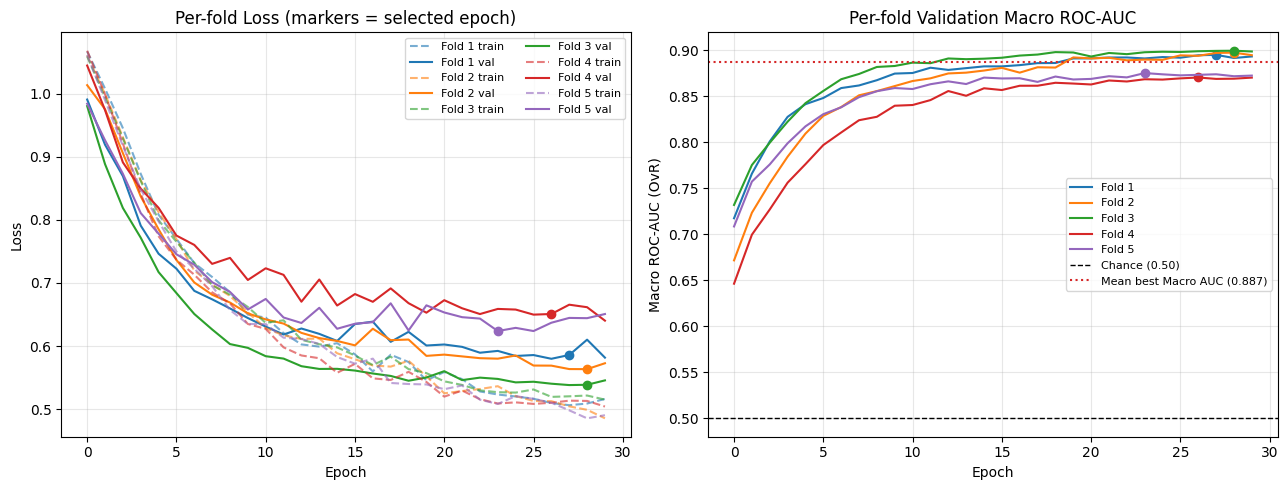

In [16]:
if len(fold_histories) > 0 and any(len(h.get('train_loss', [])) > 0 for h in fold_histories):
    fig, (loss_ax, auc_ax) = plt.subplots(1, 2, figsize=(13, 5))
    colors = plt.get_cmap('tab10').colors

    for f, h in enumerate(fold_histories):
        c = colors[f % len(colors)]
        loss_ax.plot(h['train_loss'], color=c, linestyle='--', alpha=0.6,
                     label=f'Fold {f + 1} train')
        loss_ax.plot(h['val_loss'], color=c, label=f'Fold {f + 1} val')
        loss_ax.plot(h['best_epoch'], h['best_val_loss'], 'o', color=c, markersize=6)

        auc_ax.plot(h['val_auc'], color=c, label=f'Fold {f + 1}')
        auc_ax.plot(h['best_epoch'], h['best_val_auc'], 'o', color=c, markersize=6)

    loss_ax.set_xlabel('Epoch')
    loss_ax.set_ylabel('Loss')
    loss_ax.set_title('Per-fold Loss (markers = selected epoch)')
    loss_ax.legend(fontsize=8, ncol=2)
    loss_ax.grid(alpha=0.3)

    auc_ax.axhline(0.5, color='k', linestyle='--', lw=1, label='Chance (0.50)')
    auc_ax.axhline(cv_summary['val_auc_mean'], color='tab:red', linestyle=':', lw=1.5,
                   label=f"Mean best Macro AUC ({cv_summary['val_auc_mean']:.3f})")
    auc_ax.set_xlabel('Epoch')
    auc_ax.set_ylabel('Macro ROC-AUC (OvR)')
    auc_ax.set_title('Per-fold Validation Macro ROC-AUC')
    auc_ax.legend(fontsize=8)
    auc_ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
elif len(fold_histories) > 0:
    # Checkpoint-load path: only best-epoch scalars are available; plot a bar summary.
    fig, ax = plt.subplots(figsize=(8, 4))
    aucs = [h['best_val_auc'] for h in fold_histories]
    ax.bar([f'Fold {i + 1}' for i in range(len(aucs))], aucs, color='steelblue')
    ax.axhline(cv_summary['val_auc_mean'], color='tab:red', linestyle=':', lw=1.5,
               label=f"Mean Macro AUC ({cv_summary['val_auc_mean']:.3f})")
    ax.set_ylabel('Val Macro ROC-AUC')
    ax.set_title('Loaded Fine-Tuned Fold Checkpoints (val Macro AUC)')
    ax.set_ylim(0.5, 1.0)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("No training history to plot.")

In [17]:
if not completed_path:
    for i, fold_model in enumerate(fold_models):
        fold_save_path = os.path.join(completed_dir, f'fold_{i + 1}.pth')
        torch.save(fold_model.state_dict(), fold_save_path)
    print(f"Saved {len(fold_models)} fold models to {completed_dir}")

    save_path = os.path.join(completed_dir, 'completed.pth')
    torch.save(model.state_dict(), save_path)
    print(f"Best fold (fold {best_fold + 1}) saved to {save_path}")
else:
    print(f"Skipped overwrite; using existing checkpoints under {completed_dir}")
    print(f"  completed.pth + fold_1..fold_{len(fold_models)}.pth already loaded")

Saved 5 fold models to ../models/Resnet/completed
Best fold (fold 3) saved to ../models/Resnet/completed\completed.pth


# Testing and Visualization

## Visualization

In [18]:
def test_and_visualize(model, loader, device, num_samples=3):
    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    class_names = ['background', 'benign', 'malignant']

    num_to_plot = min(num_samples, images.size(0))
    fig, axes = plt.subplots(1, num_to_plot, figsize=(15, 4))

    if num_to_plot == 1:
        axes = [axes]

    for i in range(num_to_plot):
        ax = axes[i]
        img = inv_transform(images[i])

        img = img.permute(1, 2, 0).numpy()

        img = np.clip(img, 0, 1)

        ax.imshow(img)

        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]

        color = 'green' if preds[i] == labels[i] else 'red'
        ax.set_title(f"True: {true_label}, Pred: {pred_label}", color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

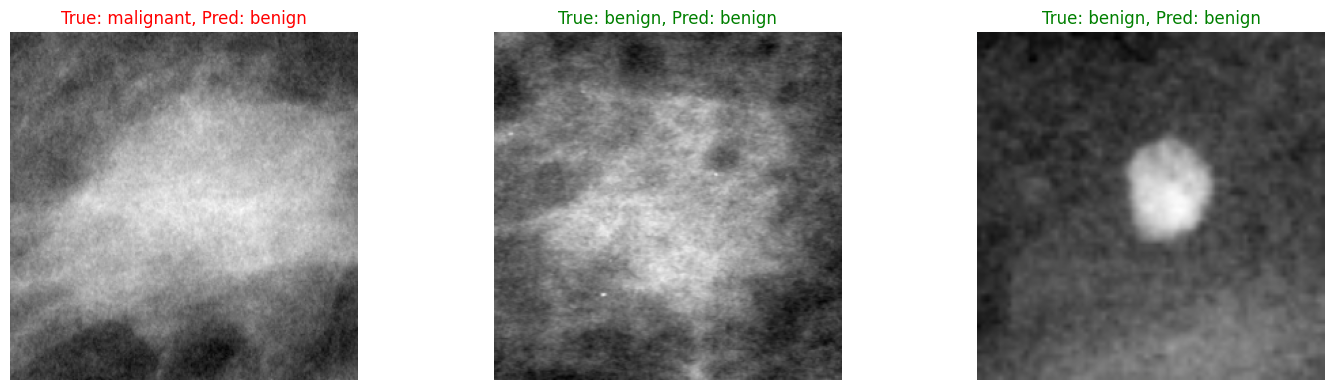

In [19]:
test_and_visualize(model, test_loader, device)

## Evaluation

Test Loss: 0.6050
Test Accuracy: 0.7076
Test Macro ROC-AUC: 0.8744

Classification Report:
              precision    recall  f1-score   support

  background       0.82      0.89      0.85        85
      benign       0.74      0.69      0.72       264
   malignant       0.61      0.64      0.63       188

    accuracy                           0.71       537
   macro avg       0.72      0.74      0.73       537
weighted avg       0.71      0.71      0.71       537

Sensitivity (Recall) for background: 76/85 -> 0.894
Sensitivity (Recall) for benign: 183/264 -> 0.693
Sensitivity (Recall) for malignant: 121/188 -> 0.644


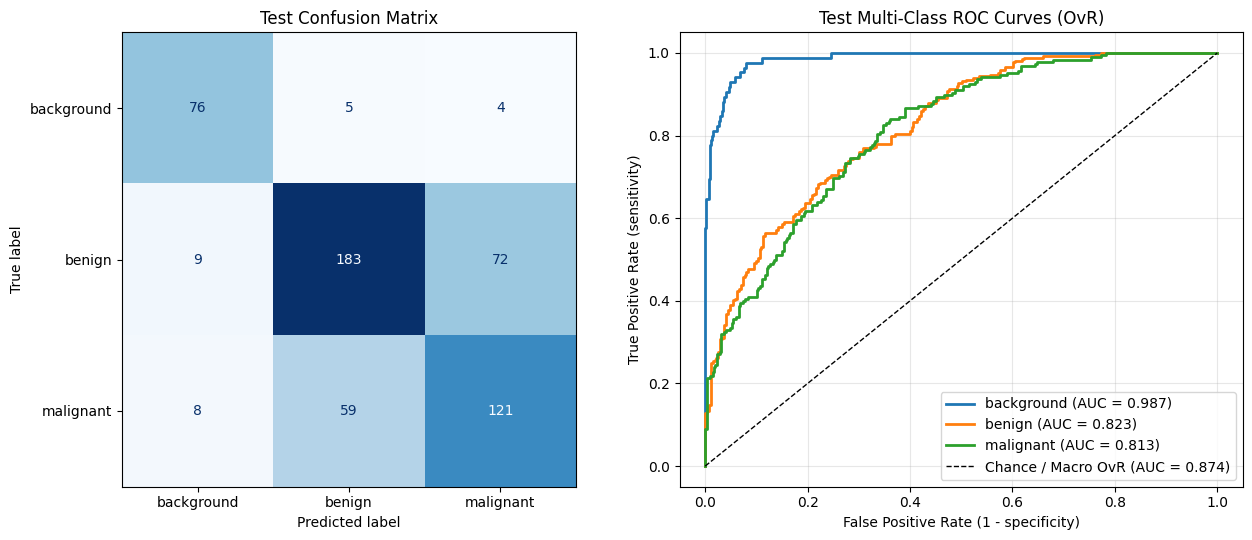

Reported Test Macro ROC-AUC: 0.8744
Confusion matrix:
[[ 76   5   4]
 [  9 183  72]
 [  8  59 121]]


In [20]:
# Held-out test split only (never used in CV training).
# Fine-tuned normalized-data model: expect Macro ROC-AUC >= 0.86 with balanced class recalls.
test_metrics = evaluate_model(
    model, test_loader, criterion, device,
    split_name='Test',
    class_names=['background', 'benign', 'malignant'],
)
print(f"Reported Test Macro ROC-AUC: {test_metrics['auc']:.4f}")
print(f"Confusion matrix:\n{test_metrics['confusion_matrix']}")

In [21]:
# Ensemble the folds: average softmax probability vectors across all fold models. This is usually worth a
# point or two of Macro ROC-AUC over any single fold and costs nothing but inference time.
fold_probs = []
test_labels = None

for fold_model in fold_models:
    labels, probs, _ = run_inference(fold_model, test_loader, criterion, device)
    fold_probs.append(probs)
    test_labels = labels

ensemble_probs = np.mean(fold_probs, axis=0)

ensemble_macro_auc = roc_auc_score(test_labels, ensemble_probs, multi_class='ovr', average='macro')
best_single_macro_auc = max(roc_auc_score(test_labels, p, multi_class='ovr', average='macro') for p in fold_probs)

print(f"Ensemble test Macro ROC-AUC (OvR): {ensemble_macro_auc:.4f}")
print(f"Best single fold test Macro ROC-AUC (OvR): {best_single_macro_auc:.4f}")

Ensemble test Macro ROC-AUC (OvR): 0.8765
Best single fold test Macro ROC-AUC (OvR): 0.8761
